In [13]:
# %matplotlib widget

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from scipy.fftpack import rfft, rfftfreq
from typing import List

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Noto Serif CJK SC'] + plt.rcParams['font.serif']
plt.rcParams['lines.linewidth'] = 1

In [14]:
# Data processing

data_list = {}

csv_list = ['1.5.2.1', '1.5.2.2']
for i in csv_list:
    data_list[i] = pd.read_csv(i + '.csv')

def process_log_time_domain(data_lines):
    flag_is_real_data = False
    data = []
    for line in data_lines:
        if line.startswith('time[0]'):
            flag_is_real_data = True
            continue
        if flag_is_real_data:
            if line == '\n':
                break
            data.append(float(line.rstrip('\n').split('\t')[1]))
    return np.array(data)

def process_log_spectrum(data_lines):
    flag_is_real_data = False
    freqs, dbvmss = [], []
    for line in data_lines:
        if line.startswith('Units'):
            flag_is_real_data = True
            continue
        if flag_is_real_data:
            if line == '\n':
                break
            freq, dbvms = [float(_) for _ in line.rstrip('\n').split('\t')]
            freqs.append(freq)
            dbvmss.append(dbvms)
    return np.array(freqs), np.array(dbvmss)

def process_log(data_lines, mode):
    if mode == 'time_domain':
        return process_log_time_domain(data_lines)
    elif mode == 'spectrum':
        return process_log_spectrum(data_lines)
    else:
        raise ValueError

log_list = ['1.5.3.spectrum', '1.5.3.time_domain', '1.5.4.sampled.spectrum', '1.5.4.sampled.time_domain', '1.5.4.sampling.spectrum', '1.5.4.sampling.time_domain']
raw_data_list = {}
for i in log_list:
    with open(i + '.log', 'r', encoding='utf-8') as f:
        raw_data_list[i] = f.readlines()
        data_list[i] = process_log(raw_data_list[i], i.rsplit('.', maxsplit=1)[-1])
data_list['1.5.3.from_spectrum.time_domain'] = process_log(raw_data_list['1.5.3.spectrum'], 'time_domain')

def split_array(arr):
    arrs = np.vsplit(arr.T, arr.shape[1]) # a list of 2-d arrays in shape of (1, N)
    return [_.flatten() for _ in arrs] # flatten all sub-arrays

def split_csv(data): # only for compatibility
    return split_array(data.values)

In [15]:
# Graph manipulation

def plot_wrapper(plot_func):
    def inner(*args, **params):
        params = defaultdict(lambda: None, params)
        fig = plt.figure(num=params['num'], figsize=params['figsize'], clear=True, layout='constrained')
        ax = fig.add_subplot()
        plot_func(fig, ax, *args, **params)
        fig.suptitle(params['title'])
        plt.grid(True)
        plt.savefig(params['num'] + '.png')
        plt.show()
    return inner

@plot_wrapper
def plot_filter(fig, ax, freqs, amps, **params):
    ax.plot(freqs, amps)
    #ax.scatter(freqs, amps)
    ax.set_xlabel(r'Frequency (Hz)')
    ax.set_ylabel(r'Amplitude (V)')

@plot_wrapper
def plot_time_domain(fig, ax, amps, dt, **params):
    N = amps.size
    t = np.linspace(0, dt * N, N, endpoint=False)
    ax.plot(t, amps)
    ax.set_xlabel(r'Time (s)')
    ax.set_ylabel(r'Amplitude (V)')

@plot_wrapper
def plot_spectrum(fig, ax, freqs, dbvmss, **params):
    ax.plot(freqs, dbvmss)
    ax.set_xlabel(r'Frequency (Hz)')
    ax.set_ylabel(r'Magnitude (dBVms)')

@plot_wrapper
def plot_spectrum_with_fft(fig, ax, freqs, dbvmss, amps, dt, **params):
    N = amps.size
    Y = rfft(amps) * 2 # Because there is only one half of spectrum
    Y_amp_norm = abs(Y) / N
    Y_amp_norm_db = 20 * np.log10(Y_amp_norm)
    X = rfftfreq(N, dt)
    idx = np.argsort(X)
    ax.plot(X[idx], Y_amp_norm_db[idx], label='DFT')
    ax.plot(freqs, dbvmss, label='Measured')
    ax.legend()
    ax.set_xlabel(r'Frequency (Hz)')
    ax.set_ylabel(r'Magnitude (dBV)')

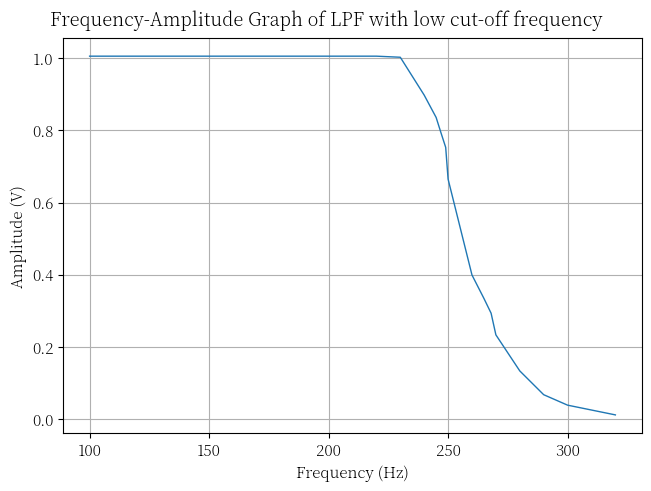

In [16]:
# 1.5.2.1

LABEL = '1.5.2.1'
plot_filter(*split_csv(data_list[LABEL]), title='Frequency-Amplitude Graph of LPF with low cut-off frequency', num=LABEL)

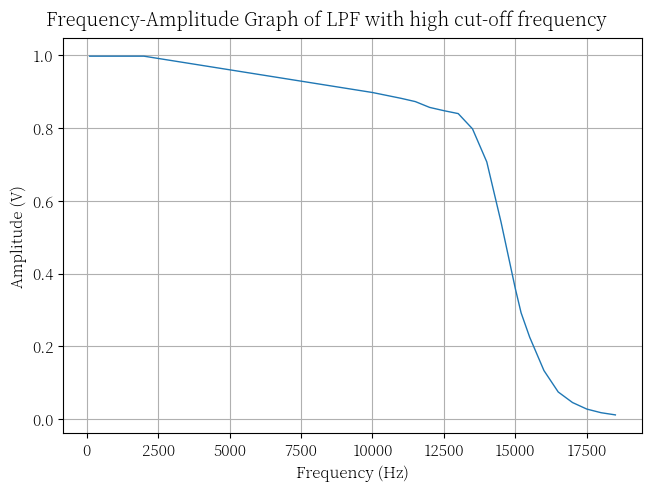

In [17]:
# 1.5.2.2

LABEL = '1.5.2.2'
plot_filter(*split_csv(data_list[LABEL]), title='Frequency-Amplitude Graph of LPF with high cut-off frequency', num=LABEL)

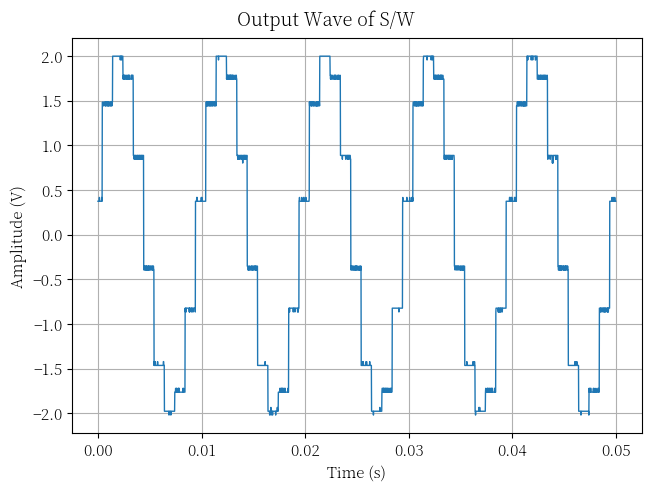

In [18]:
# 1.5.3.time_domain

LABEL = '1.5.3.time_domain'
plot_time_domain(data_list[LABEL], 2e-5, title='Output Wave of S/W', num=LABEL)

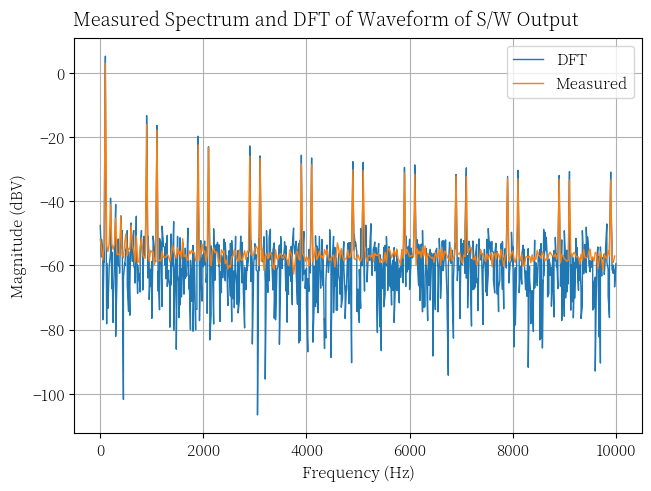

In [19]:
# 1.5.3.spectrum

LABEL = '1.5.3.spectrum'
plot_spectrum_with_fft(*data_list[LABEL], data_list['1.5.3.from_spectrum.time_domain'], 5e-5, title='Measured Spectrum and DFT of Waveform of S/W Output', num=LABEL)

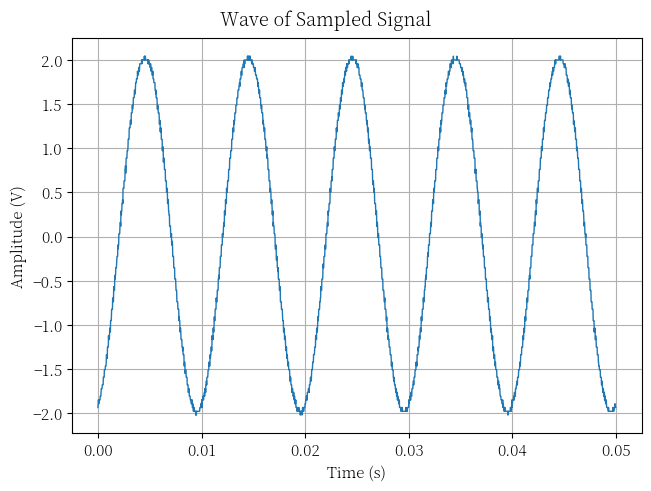

In [20]:
# 1.5.4.sampled.time_domain

LABEL = '1.5.4.sampled.time_domain'
plot_time_domain(data_list[LABEL], 2e-5, title='Wave of Sampled Signal', num=LABEL)

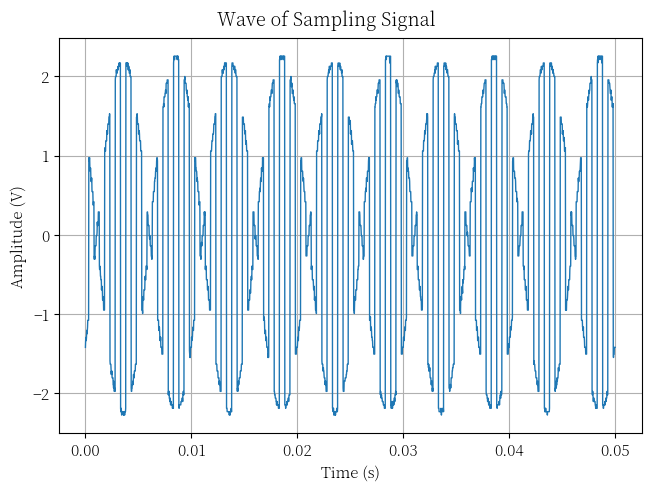

In [21]:
# 1.5.4.sampling.time_domain

LABEL = '1.5.4.sampling.time_domain'
plot_time_domain(data_list[LABEL], 2e-5, title='Wave of Sampling Signal', num=LABEL)

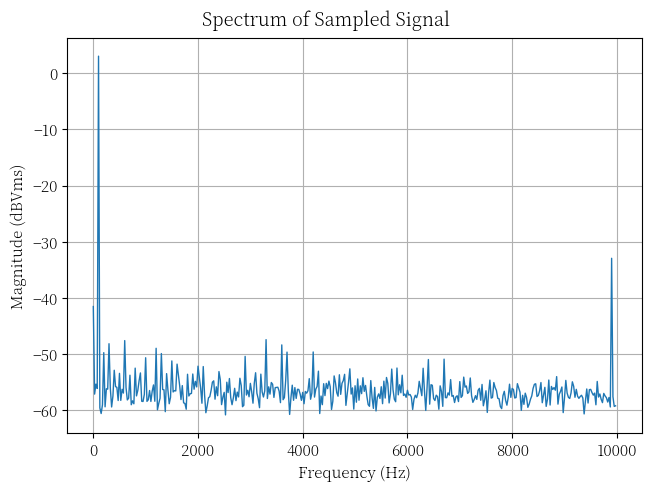

In [22]:
# 1.5.4.sampled.spectrum

LABEL = '1.5.4.sampled.spectrum'
plot_spectrum(*data_list[LABEL], title='Spectrum of Sampled Signal', num=LABEL)

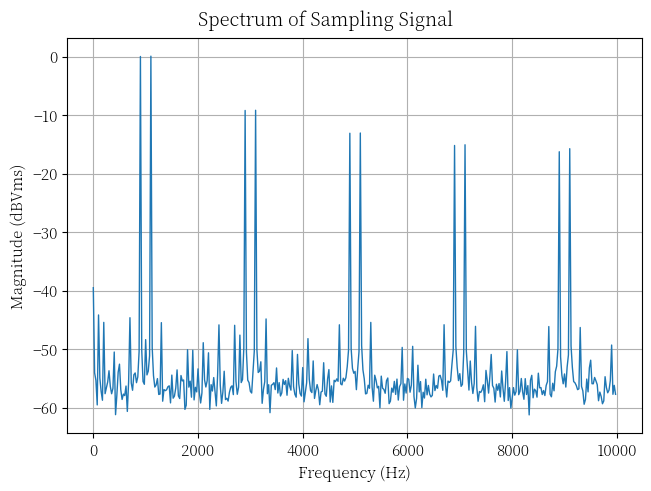

In [23]:
# 1.5.4.sampling.spectrum

LABEL = '1.5.4.sampling.spectrum'
plot_spectrum(*data_list[LABEL], title='Spectrum of Sampling Signal', num=LABEL)